In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hiopbbpy.problems import Problem
from hiopbbpy.surrogate_modeling import smtKRG 
from hiopbbpy.opt import BnBAlgorithmBase, LCBacquisition

#### Example 

In [2]:
### parameters
n_samples = 10  # number of the initial samples to train GP
theta = 1.e-2  # hyperparameter for GP kernel
nx = 1         # dimension of the problem
c2D=np.array([1.25, 2.5])
c1D=np.array([1.25])
if nx == 1:
    delta = 10.0
    xlimits = np.array([[0.75 - delta/2.,0.75 + delta/2.]])
    c1D = np.array([0.75])
    c = c1D
elif nx == 2:
    c = c2D

class QuadraticShift(Problem):
    """
    f(x) = ||x - c||^2
    - Global minimizer: x* = c
    - Global minimum:   f* = 0
    """
    def __init__(self, ndim=2, xlimits=None, c=None, constraints=[]):
        if xlimits is None:
            xlimits = np.array([[-5.0, 5.0]] * ndim, dtype=float)
        name = "QuadraticShift"
        super().__init__(ndim, xlimits, name=name, constraints=constraints)

        # choose center if not provided
        if c is None:
            c = self.xlimits.mean(axis=1)
        self.c = np.asarray(c, dtype=float)
        assert self.c.shape == (ndim,), "c must be a {0:d}D point".format(ndim)

        # expose known solution for checking later
        # below is true when c is in xlimits
        self.x_star = self.c.copy()
        self.f_star = 0.0 

    def _evaluate(self, x: np.ndarray) -> np.ndarray:
        ne, nx = x.shape
        assert nx == self.ndim
        diff = x - self.c[None, :]
        y = np.sum(diff * diff, axis=1, dtype=float).reshape(ne, 1)
        return y

if nx == 1:
    problem = QuadraticShift(ndim=nx, xlimits=xlimits, c=c)
else:
    problem = QuadraticShift(ndim=nx, c=c)
problem.set_constraints([])  
    
x_train = problem.sample(n_samples)
y_train = problem.evaluate(x_train)

gp_model = smtKRG(theta, problem.xlimits, nx)
gp_model.train(x_train, y_train)

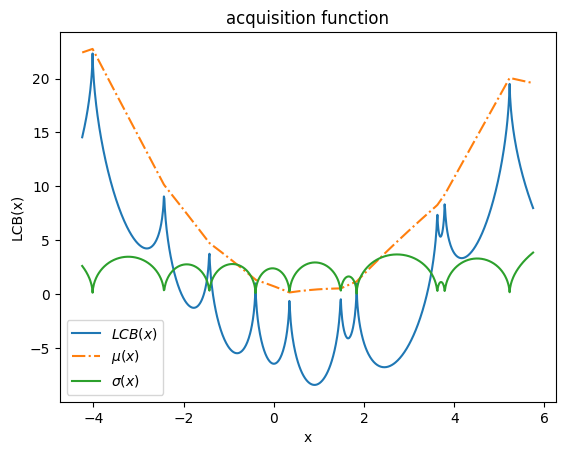

In [3]:
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)
n_plot_pts = 1000
X = np.atleast_2d(np.linspace(l[0], u[0], n_plot_pts)).transpose()

muX = gp_model.mean(X)
sigmaX = np.sqrt(gp_model.variance(X))
beta = 3.0

acqf = LCBacquisition(gp_model, beta=beta)
Y_acqf = acqf.evaluate(X)

plt.plot(X, Y_acqf, label=r'$LCB(x)$')
plt.plot(X, muX, "-.", label=r'$\mu(x)$')
plt.plot(X, sigmaX, label=r'$\sigma(x)$')
plt.xlabel("x")
plt.ylabel("LCB(x)")
plt.legend()
plt.title("acquisition function")
plt.show()

In [4]:
# Build a base "probe" and populate it from the trained SMT model
base = BnBAlgorithmBase(x=x_train, y=y_train)
base.gpsurrogate = gp_model
base.sync_from_smt()              # fills kernel_spec/p, theta, Xc, offsets, beta0/gamma, C, sigma2

# (Optional) ensure we try to compute a nontrivial lower bound for variance
base.BnB_LBmethod = None          # if "IPOPT", sigma2_L will be 0 in your current code
base.beta = beta
# Pick a box to test (use full domain here; swap l/u to any node box you want)
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)

nboxes = 250
box_sizes = (u - l) / float(nboxes)
midpoints = np.zeros((nboxes,))
kLs = np.zeros((nboxes, n_samples))
kUs = np.zeros((nboxes, n_samples))
muLs = np.zeros((nboxes,))
muUs = np.zeros((nboxes,))
s2Ls = np.zeros((nboxes,))
s2Us = np.zeros((nboxes,))
LCB_Ls = np.zeros((nboxes,) * nx)
LCB_Us = np.zeros((nboxes,) * nx)


for i in range(nboxes):
    for j in range(nboxes):
        if nx == 2:
            li = l + np.array([i * box_sizes[0], j * box_sizes[1]])
            ui = l + np.array([(i + 1) * box_sizes[0], (j +1) * box_sizes[1]])
        else:
            if j > 0:
                continue
            li = l + i * box_sizes[0]
            ui = l + (i + 1) * box_sizes[0]
        midpoints[i] = (li[0] + ui[0]) / 2.

        # 1) Bounds from your base class 
        kL, kU         = base.ker_bounds(li, ui)     # per-point kernel bounds vs each trainingsample
        mu_L, mu_U     = base.mu_bounds(kL, kU)      # scalar μ bounds on the box
        s2_L, s2_U     = base.sigma2_bounds(kL, kU,l=li,u=ui)  # scalar σ² bounds on the box
        
        # 2) (Optional) Node LCB/EI bounds using ONLY base.rs_* with your bounds
        LCB_L = base.rs_lcb(mu_L, np.sqrt(max(s2_U, 0.0)))     # lower bound on LCB over the box
        LCB_U = base.rs_lcb(mu_U, np.sqrt(max(s2_L, 0.0)))     # upper bound on LCB over the box
        
        if nx == 1:
            LCB_Ls[i] = LCB_L
            LCB_Us[i] = LCB_U
            midpoints[i] = (li[0] + ui[0]) / 2.
        elif nx == 2:
            LCB_Ls[i][j] = LCB_L
            LCB_Us[i][j] = LCB_U
        
        

        muLs[i] = mu_L
        muUs[i] = mu_U
        s2Ls[i] = s2_L
        s2Us[i] = s2_U
        kLs[i,:] = kL[:]
        kUs[i,:] = kU[:]       
mu = gp_model.mean(midpoints)
s2 = gp_model.variance(midpoints)

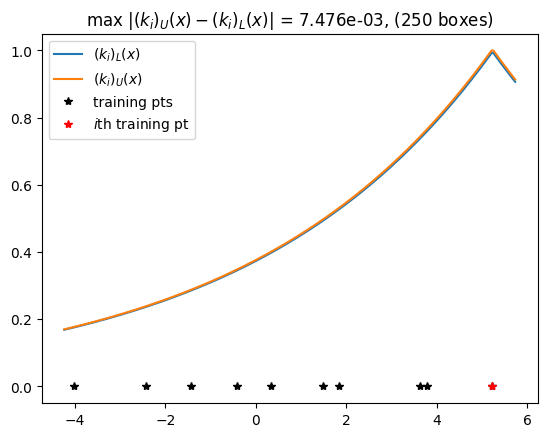

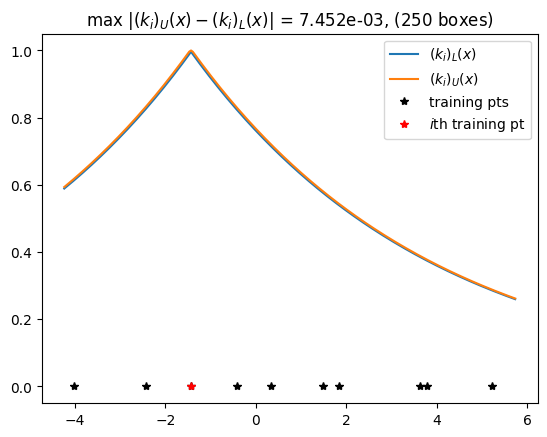

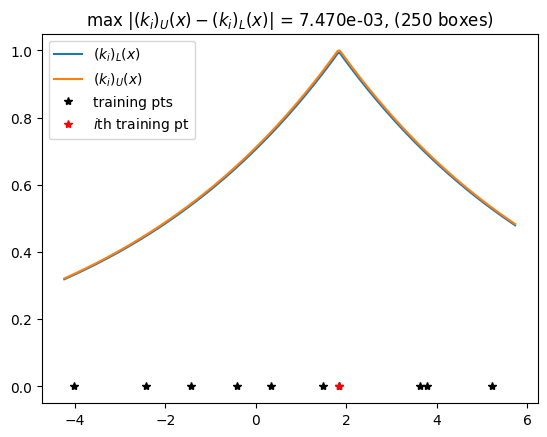

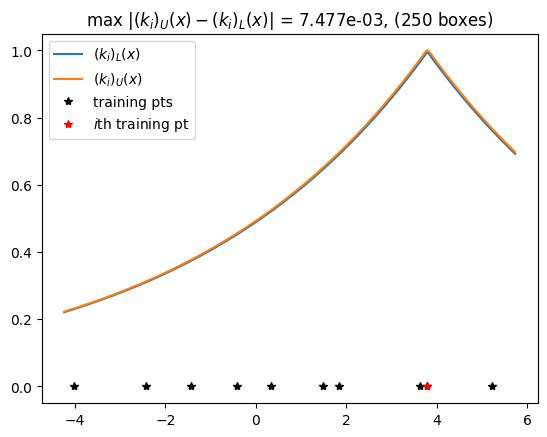

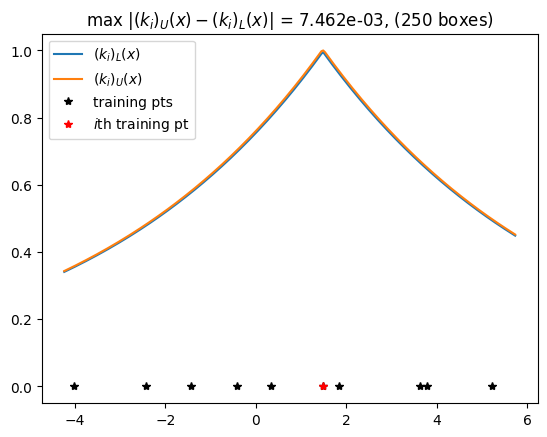

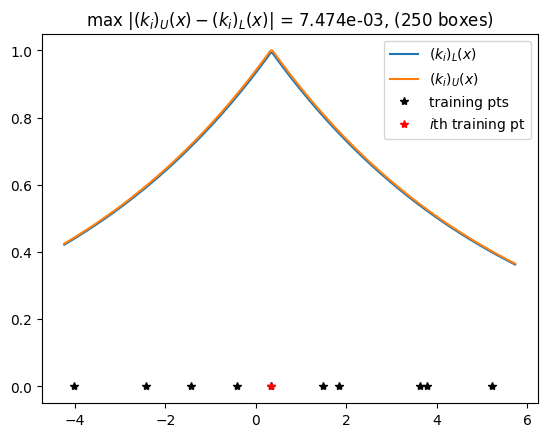

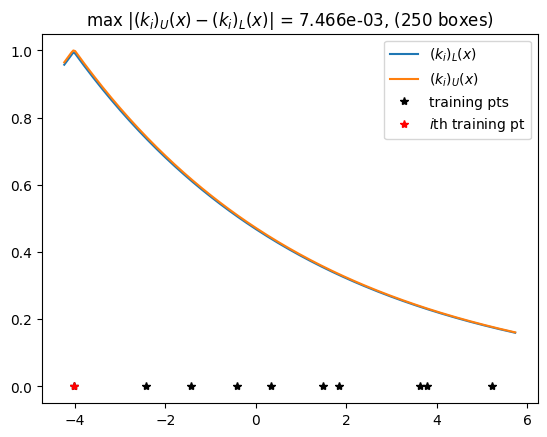

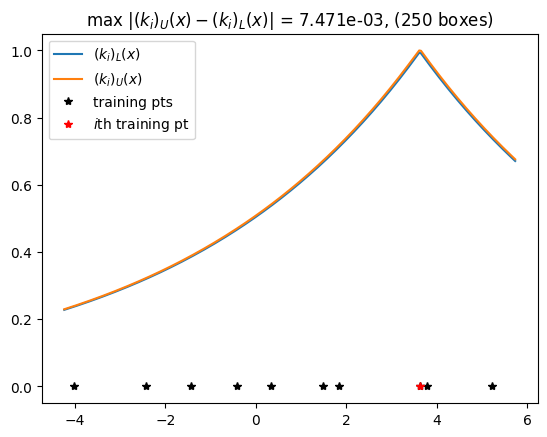

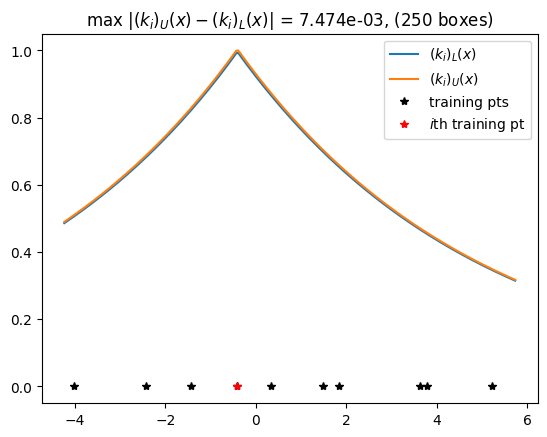

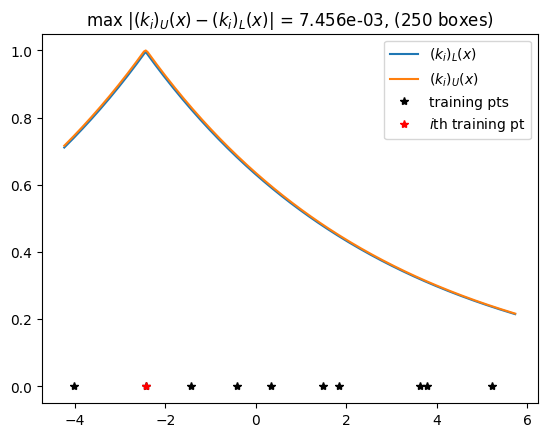

In [5]:
K_bandgaps = [np.linalg.norm(kUs[:,i] - kLs[:,i], np.inf) for i in range(n_samples)]

for i in range(n_samples):
    plt.plot(midpoints, kLs[:,i], label=r'$(k_i)_L(x)$')
    plt.plot(midpoints, kUs[:,i], label=r'$(k_i)_U(x)$')
    plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
    plt.plot(x_train[i,0], np.zeros(1), "r*", label=r'$i$th training pt')
    plt.legend()
    plt.title(r"max $|(k_i)_U(x) - (k_i)_L(x)|$ = {0:1.3e}, ({1:d} boxes)".format(K_bandgaps[i], nboxes))
    plt.show()

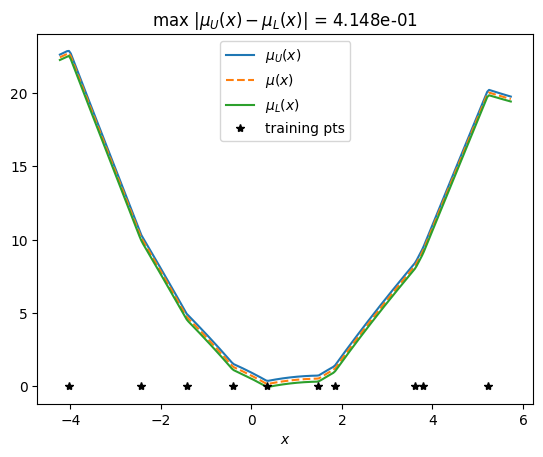

In [6]:
mu_bandgap = np.linalg.norm(muUs - muLs, np.inf)

plt.plot(midpoints, muUs, label=r'$\mu_U(x)$')
plt.plot(midpoints, mu, "--", label=r'$\mu(x)$')
plt.plot(midpoints, muLs, label=r'$\mu_L(x)$')
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.xlabel(r"$x$")
plt.legend()
plt.title(r"max $|\mu_U(x) - \mu_L(x)|$ = {0:1.3e}".format(mu_bandgap))
plt.show()

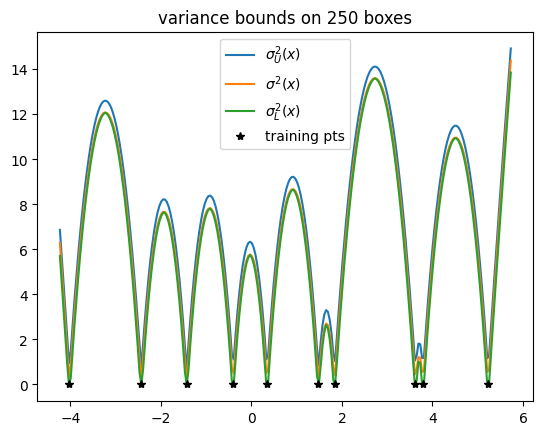

In [7]:
plt.plot(midpoints, s2Us, label=r"$\sigma^{2}_{U}(x)$")
plt.plot(midpoints, s2, label=r"$\sigma^{2}(x)$")
plt.plot(midpoints, s2Ls, label=r"$\sigma^{2}_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('variance bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

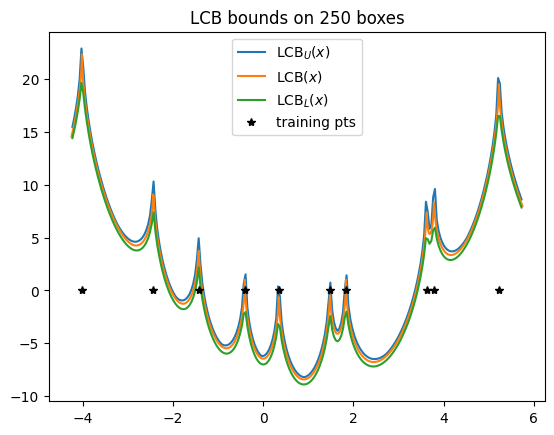

In [8]:
plt.plot(midpoints, LCB_Us, label=r"LCB$_{U}(x)$")
plt.plot(X, Y_acqf, label=r'LCB$(x)$')
plt.plot(midpoints, LCB_Ls, label=r"LCB$_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('LCB bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

In [9]:
from hiopbbpy.opt import minimizer_wrapper

In [10]:
acqf_callback = {'obj': acqf.scalar_evaluate}
acqf_callback['grad'] = acqf.scalar_eval_g
opt_solver = None
acqf_minimizer=minimizer_wrapper(acqf_callback, opt_solver, problem.xlimits, [], {})

In [11]:
from hiopbbpy.opt import BnBAlgorithm
bnb = BnBAlgorithm(x_train, y_train, gpsurrogate=gp_model, 
                   acqf_minimizer=acqf_minimizer,
                   acquisition_type="LCB")
bnb.epsilon_diam = 1.e-2
bnb.epsilon_gap = 1.e-2
bnb.BnB_LBmethod = None

In [12]:
LCB_Ls2 = np.zeros((nboxes,) * nx)
LCB_Us2 = np.zeros((nboxes,) * nx)

for i in range(nboxes):
    for j in range(nboxes):
        if nx == 2:
            li = l + np.array([i * box_sizes[0], j * box_sizes[1]])
            ui = l + np.array([(i + 1) * box_sizes[0], (j +1) * box_sizes[1]])
        else:
            if j > 0:
                continue
            li = l + i * box_sizes[0]
            ui = l + (i + 1) * box_sizes[0]
        midpoints[i] = (li[0] + ui[0]) / 2.

        # 1) Bounds from your base class 
        kL, kU         = bnb.ker_bounds(li, ui)     # per-point kernel bounds vs each trainingsample
        mu_L, mu_U     = bnb.mu_bounds(kL, kU)      # scalar μ bounds on the box
        s2_L, s2_U     = bnb.sigma2_bounds(kL, kU)  # scalar σ² bounds on the box
        
        # 2) (Optional) Node LCB/EI bounds using ONLY base.rs_* with your bounds
        LCB_L = bnb.rs_lcb(mu_L, np.sqrt(s2_U))
        LCB_U = bnb.rs_lcb(mu_U, np.sqrt(s2_L))
        LCB_L2 = bnb.compute_acq_lower_bound(li, ui)
        LCB_U2 = bnb.compute_acq_upper_bound(li, ui)
        #LCB_L = bnb.rs_lcb(mu_L, np.sqrt(max(s2_U, 0.0)))     # lower bound on LCB over the box
        #LCB_U = bnb.rs_lcb(mu_U, np.sqrt(max(s2_L, 0.0)))     # upper bound on LCB over the box
        #print(f"LCB node bounds:  L={LCB_L:.9f}   U={LCB_U:.9f}")
        if nx == 1:
            LCB_Ls[i] = LCB_L
            LCB_Us[i] = LCB_U
            LCB_Ls2[i] = LCB_L2
            LCB_Us2[i] = LCB_U2
            midpoints[i] = (li[0] + ui[0]) / 2.
        elif nx == 2:
            LCB_Ls[i][j] = LCB_L
            LCB_Us[i][j] = LCB_U
        
        

        muLs[i] = mu_L
        muUs[i] = mu_U
        s2Ls[i] = s2_L
        s2Us[i] = s2_U
        kLs[i,:] = kL[:]
        kUs[i,:] = kU[:] 

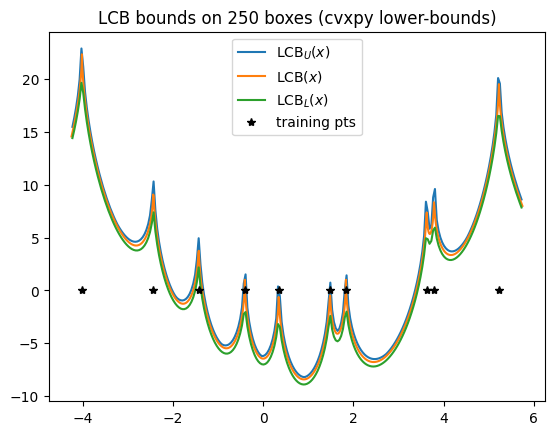

In [13]:
plt.plot(midpoints, LCB_Us2, label=r"LCB$_{U}(x)$")
plt.plot(X, Y_acqf, label=r'LCB$(x)$')
plt.plot(midpoints, LCB_Ls2, label=r"LCB$_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
if bnb.BnB_LBmethod == None:
    plt.title('LCB bounds on {0:d} boxes (cvxpy lower-bounds)'.format(nboxes))
else:
    plt.title('LCB bounds on {0:d} boxes (IPOPT lower-bounds)'.format(nboxes))
plt.legend()
plt.show()

In [14]:
bnb.max_bnbiter = 500
xstar = bnb.bnboptimize(problem.xlimits[:,0], problem.xlimits[:,1])

=== Starting Branch & Bound Optimization (Minimization) ===
Initial bounds: l = [-4.25], u = [5.75]
Number of points: 10, Dim = 1

Initial acquisition lower bound: -53.19935584095212
Initial acquisition upper bound: 49.29910407978539

--- BnB Iteration 1 ---
Node bounds: l=[-4.25], u=[5.75]
Node acquisition bounds: L=-53.19935584095212, U=49.29910407978539
Current best feasible value (GUB): 49.29910407978539
  Branching to child: l=[-4.25], u=[0.75]
  Child acquisition bounds: L=-35.54931478228122, U=30.505216557365944
  Branching to child: l=[0.75], u=[5.75]
  Child acquisition bounds: L=-35.46520986218328, U=28.990987006375693
Queue size: 2 | GLB=-35.54931478228122 | GUB=28.990987006375693 | Gap=64.54030178865692

--- BnB Iteration 2 ---
Node bounds: l=[-4.25], u=[0.75]
Node acquisition bounds: L=-35.54931478228122, U=30.505216557365944
Current best feasible value (GUB): 28.990987006375693
  Branching to child: l=[-4.25], u=[-1.75]
  Child acquisition bounds: L=-15.557624416561923, U

  Child acquisition bounds: L=-9.043743745461908, U=-4.163295700032613
  Branching to child: l=[2.9375], u=[3.25]
  Child acquisition bounds: L=-7.060853651604244, U=-1.2132380405810226
  Child pruned: L ≥ GUB - eps.
Queue size: 15 | GLB=-10.940228387518744 | GUB=-7.278853901371688 | Gap=3.6613744861470554

--- BnB Iteration 20 ---
Node bounds: l=[0.4375], u=[0.75]
Node acquisition bounds: L=-10.940228387518744, U=-2.8916217234297106
Current best feasible value (GUB): -7.278853901371688
  Branching to child: l=[0.4375], u=[0.59375]
  Child acquisition bounds: L=-8.286859645713779, U=-3.732388147310785
  Branching to child: l=[0.59375], u=[0.75]
  Child acquisition bounds: L=-9.605971577889804, U=-6.1565420519811935
Queue size: 16 | GLB=-10.846865895883365 | GUB=-7.278853901371688 | Gap=3.568011994511677

--- BnB Iteration 21 ---
Node bounds: l=[1.0625], u=[1.375]
Node acquisition bounds: L=-10.846865895883365, U=-3.0623239316165023
Current best feasible value (GUB): -7.278853901371688


  Child acquisition bounds: L=-8.48937707538629, U=-7.689701034479456
Queue size: 19 | GLB=-8.871929349828491 | GUB=-8.302441703723362 | Gap=0.569487646105129

--- BnB Iteration 37 ---
Node bounds: l=[0.90625], u=[0.9453125]
Node acquisition bounds: L=-8.871929349828491, U=-8.18986473734713
Current best feasible value (GUB): -8.302441703723362
  Branching to child: l=[0.90625], u=[0.92578125]
  Child acquisition bounds: L=-8.642958607546008, U=-8.30468221222895
  Branching to child: l=[0.92578125], u=[0.9453125]
  Child acquisition bounds: L=-8.630690515847938, U=-8.287099325127194
Queue size: 20 | GLB=-8.848814476521051 | GUB=-8.30468221222895 | Gap=0.5441322642921005

--- BnB Iteration 38 ---
Node bounds: l=[0.125], u=[0.4375]
Node acquisition bounds: L=-8.848814476521051, U=1.8361072196513368
Current best feasible value (GUB): -8.30468221222895
  Branching to child: l=[0.125], u=[0.28125]
  Child acquisition bounds: L=-7.650737812001379, U=-2.8505598482534875
  Child pruned: L ≥ GUB

  Child acquisition bounds: L=-8.483174988994499, U=-8.307924224847762
Queue size: 27 | GLB=-8.599668285098875 | GUB=-8.357340642709389 | Gap=0.2423276423894869

--- BnB Iteration 54 ---
Node bounds: l=[3.25], u=[4.5]
Node acquisition bounds: L=-8.599668285098875, U=15.82876402228436
Current best feasible value (GUB): -8.357340642709389
  Branching to child: l=[3.25], u=[3.875]
  Child acquisition bounds: L=-4.566470607719481, U=11.034876317825626
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[3.875], u=[4.5]
  Child acquisition bounds: L=-3.1360203215666544, U=10.548057253234548
  Child pruned: L ≥ GUB - eps.
Queue size: 26 | GLB=-8.591282169883137 | GUB=-8.357340642709389 | Gap=0.23394152717374794

--- BnB Iteration 55 ---
Node bounds: l=[0.828125], u=[0.84765625]
Node acquisition bounds: L=-8.591282169883137, U=-8.231156936948278
Current best feasible value (GUB): -8.357340642709389
  Branching to child: l=[0.828125], u=[0.83789062]
  Child acquisition bounds: L=-8.46399503

  Child acquisition bounds: L=-8.16057114164056, U=-7.764101385528992
  Child pruned: L ≥ GUB - eps.
Queue size: 13 | GLB=-8.44790923565607 | GUB=-8.357340642709389 | Gap=0.09056859294668129

--- BnB Iteration 79 ---
Node bounds: l=[0.97460938], u=[0.984375]
Node acquisition bounds: L=-8.44790923565607, U=-8.26973446934632
Current best feasible value (GUB): -8.357340642709389
Skip: Node diameter 0.009765625 <= 0.01

--- BnB Iteration 80 ---
Node bounds: l=[0.81835938], u=[0.828125]
Node acquisition bounds: L=-8.444547320271852, U=-8.262145387167754
Current best feasible value (GUB): -8.357340642709389
Skip: Node diameter 0.009765625 <= 0.01

--- BnB Iteration 81 ---
Node bounds: l=[0.76953125], u=[0.7890625]
Node acquisition bounds: L=-8.444247694045458, U=-8.064064689020835
Current best feasible value (GUB): -8.357340642709389
  Branching to child: l=[0.76953125], u=[0.77929688]
  Child acquisition bounds: L=-8.307234207239404, U=-8.11626053111313
  Child pruned: L ≥ GUB - eps.
  Bran

In [ ]:
queue = xstar
xstar_true = np.atleast_2d(X[np.argmin(Y_acqf)])
print("queue size = ", len(queue))
for (node_L, _, node) in queue:
    if node.l[0] <= xstar_true[0][0] and node.u[0] >= xstar_true[0][0]:
        print(xstar_true[0][0], node.l[0], node.u[0])
    

In [ ]:
xstar2 = np.atleast_2d((xstar[0] + xstar[1]) /2.)

In [ ]:
y_star = acqf.evaluate(xstar2)
xstar_true = np.atleast_2d(X[np.argmin(Y_acqf)])
ystar_true = acqf.evaluate(xstar_true)
print(xstar_true)
plt.plot(X, Y_acqf, 'k--', label=r'LCB$(x)$')
plt.plot(xstar2, y_star, "r*", markersize=14, label=r'bnb minimizer')
plt.plot(xstar_true, ystar_true, "k*", markersize=12)
#for i in range(2):
#    plt.plot(xstar_bounds.flatten()[i], y_star[0,0] , "k*")
plt.title('LCB with bnb minimizer'.format(nboxes))
plt.legend()
plt.show()


In [ ]:
bo_maxiter = 3
batch_size = 1
options = {
    'acquisition_type': 'LCB',
    'acquisition_method' : 'bnb',
    'bo_maxiter': bo_maxiter, 
    'batch_size': batch_size,
    'opt_solver': "SLSQP"    
}

In [ ]:
from hiopbbpy.opt import BOAlgorithm
bo = BOAlgorithm(problem, gp_model, x_train, y_train, options=options)
bo.optimize()

In [ ]:
x_bo = bo.getOptimizationHistory()[0]
x_train_superset = np.concatenate((x_train, x_bo), axis=0)
for i in range(bo_maxiter):
    x_train2 = x_train_superset[:-bo_maxiter+i]
    y_train2 = problem.evaluate(x_train2)
    gp_model2 = smtKRG(theta, problem.xlimits, nx)
    gp_model2.train(x_train2, y_train2)
    acqf2 = LCBacquisition(gp_model2, beta=beta)
    Y_acqf2 = acqf2.evaluate(X)
    y_star2 = acqf2.evaluate(np.atleast_2d(x_bo[i]))
    plt.plot(X, Y_acqf2,'k--', label=r'$LCB(x)$')
    plt.plot(x_bo[i], y_star2, r'r*', markersize=12)
    #plt.plot(X, muX, "-.", label=r'$\mu(x)$')
    #plt.plot(X, sigmaX, label=r'$\sigma(x)$')
    plt.xlabel("x")
    plt.ylabel("LCB(x)")
    plt.legend()
    plt.title(r"LCB(x) at BO iteration {0:d}".format(i))
    plt.show()
    
    